In [2]:
import os
import scanpy as sc
import anndata as ad
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

In [4]:
# --------------------------------------------------
# 1️⃣ LOAD SAVED ANNDATA
# --------------------------------------------------

import scanpy as sc
import pandas as pd
import numpy as np
import os
from sklearn.metrics import normalized_mutual_info_score

adata = sc.read("/home/znazari/scRNAseq_parkinson/result/adata_geneformer_leiden_sweep.h5ad")
print("Loaded:", adata.shape)

# --------------------------------------------------
# 2️⃣ VERIFY METADATA EXISTS
# --------------------------------------------------

required_cols = ["disease", "tissue"]
missing = [c for c in required_cols if c not in adata.obs.columns]

if len(missing) > 0:
    raise ValueError(f"Missing metadata columns: {missing}")

print("Metadata already present.")

# --------------------------------------------------
# 3️⃣ CREATE celltype_condition
# --------------------------------------------------

adata.obs["tissue_condition"] = (
    adata.obs["tissue"].astype(str) + "_" +
    adata.obs["disease"].astype(str)
)

# --------------------------------------------------
# 4️⃣ FIND LEIDEN COLUMNS
# --------------------------------------------------

leiden_cols = [c for c in adata.obs.columns if c.startswith("leiden")]
print("Found clustering columns:", leiden_cols)

# --------------------------------------------------
# 5️⃣ COMPUTE PER-CELLTYPE NMI
# --------------------------------------------------

results = []

unique_classes = adata.obs["tissue_condition"].dropna().unique()

for cluster_key in leiden_cols:

    res = float(cluster_key.replace("leiden_r", ""))

    print(f"Processing resolution {res}")

    valid = adata.obs[[cluster_key, "tissue_condition"]].dropna()
    clusters = valid[cluster_key].astype(str)
    labels = valid["tissue_condition"].astype(str)

    for ct in unique_classes:
        binary_label = (labels == ct).astype(int)
        nmi_ct = normalized_mutual_info_score(clusters, binary_label)

        results.append({
            "resolution": res,
            "tissue_condition": ct,
            "NMI": nmi_ct
        })

nmi_df = pd.DataFrame(results)

print("NMI computation Done.")

# --------------------------------------------------
# 6️⃣ CREATE SORTED PIVOT (ONLY OUTPUT)
# --------------------------------------------------

pivot = nmi_df.pivot(
    index="tissue_condition",
    columns="resolution",
    values="NMI"
)

lowest_resolution = sorted(pivot.columns)[0]

sorted_pivot = pivot.sort_values(by=lowest_resolution, ascending=False)

output_path = "/home/znazari/scRNAseq_parkinson/result/nmi_tissue_pivot_geneformer.csv"
sorted_pivot.to_csv(output_path, index=True)

print("Final sorted pivot saved at:", output_path)

Loaded: (2096155, 512)


ValueError: Missing metadata columns: ['tissue']

In [3]:
sorted_pivot

resolution,0.3,0.5,0.8,1.0
celltype_condition,,,,
oligodendrocyte_Parkinson disease,0.302496,0.297744,0.257849,0.242669
glutamatergic neuron_Parkinson disease,0.234966,0.230851,0.195522,0.182944
astrocyte_Parkinson disease,0.206457,0.202512,0.170571,0.159047
central nervous system macrophage_Parkinson disease,0.150838,0.147172,0.123078,0.114536
GABAergic neuron_Parkinson disease,0.149142,0.146907,0.124583,0.116017
oligodendrocyte precursor cell_Parkinson disease,0.138134,0.133466,0.111505,0.103748
glutamatergic neuron_normal,0.067887,0.066745,0.055728,0.051969
oligodendrocyte_normal,0.066178,0.065118,0.056427,0.052798
GABAergic neuron_normal,0.042551,0.041877,0.035038,0.032507


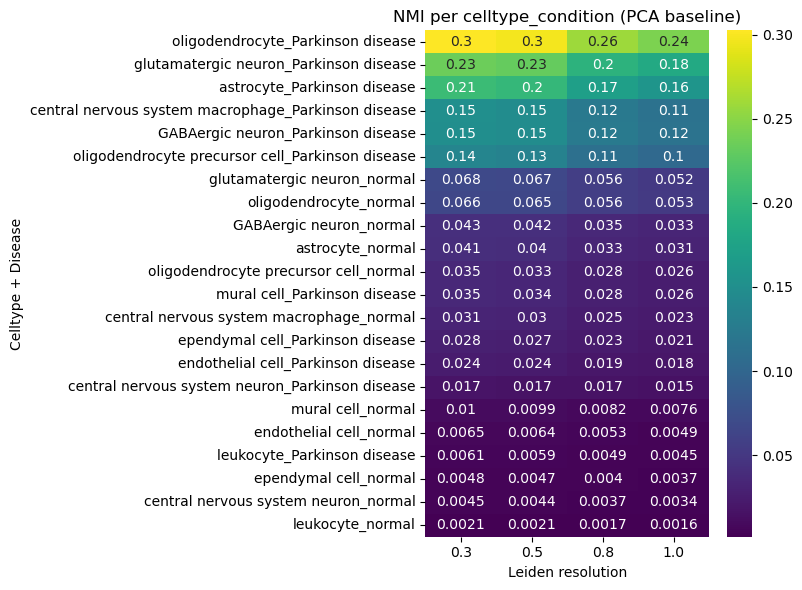

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
sorted_pivot = pd.read_csv("/home/znazari/scRNAseq_parkinson/result/nmi_table_pivot_geneformer.csv", index_col=0)
plt.figure(figsize=(8,6))
sns.heatmap(sorted_pivot, annot=True, cmap="viridis")
plt.title("NMI per celltype_condition (PCA baseline)")
plt.xlabel("Leiden resolution")
plt.ylabel("Celltype + Disease")
plt.tight_layout()
plt.show()